In [57]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from kneed import KneeLocator  # pip install kneed

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import curvature as curve

In [58]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 6.34 GB, difference +3.40 GB
CPU times: user 12.5 s, sys: 2.82 s, total: 15.3 s
Wall time: 19.9 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [59]:
npath = "/scratch/indikar_root/indikar1/jduhamel/pore_c/curvature/nodes_curvature.csv"
node_df = pd.read_csv(npath)

print(node_df.head())

   node_id  chrom_bin chrom  bin_start    bin_end  degree  scalar_curvature  \
0        0        121     9  121000000  122000000    3054          -9300499   
1        1         26    19   26000000   27000000    2886          -8314541   
2        2        127     4  127000000  128000000    3275         -10683981   
3        3         57    10   57000000   58000000    2819          -7936616   
4        4          8    12    8000000    9000000    3057          -9343189   

   normalized_scalar_curvature  
0                 -3045.350033  
1                 -2880.991337  
2                 -3262.284275  
3                 -2815.401206  
4                 -3056.326137  


In [60]:
# filter
H = adata.X.tocsr().astype(float)
print(f"raw shape = {H.shape}")

raw shape = (2579, 2756467)


In [61]:
# IQR filter on locus degree (rows)
s = np.asarray(H.sum(axis=1)).ravel()
q1, q3 = np.quantile(s, [0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
row_mask = (s >= low) & (s <= high)

H = H[row_mask, :]
obs_idx = np.where(row_mask)[0] 

In [62]:
# drop singletons (reads with < 2 loci after row filter)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums >= 2
H = H[:, col_mask]
var_idx = np.where(col_mask)[0]          # maps H cols -> adata.var cols

In [63]:
# drop large hyperedges (reads with > 10 loci)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums <= 10
H = H[:, col_mask]
var_idx = var_idx[col_mask]

print(f"filtered shape = {H.shape}")

filtered shape = (2335, 2039865)


In [64]:
print(f"filtered shape = {H.shape}")
print(f"node_df rows: {len(node_df)}  (should equal H rows: {H.shape[0]})")
assert len(node_df) == H.shape[0], "Mismatch: check that node_df was built from the same obs_idx filter"

filtered shape = (2335, 2039865)
node_df rows: 2335  (should equal H rows: 2335)


In [65]:
## Modifying the curvature values
curvature_val = node_df["normalized_scalar_curvature"].values
curve_mod=[]

for i in curvature_val:
    curve_mod.append(abs(i))

node_df["abs_normalized_scalar_curvature"] = curve_mod


### Node Curvature Scores - Histogram

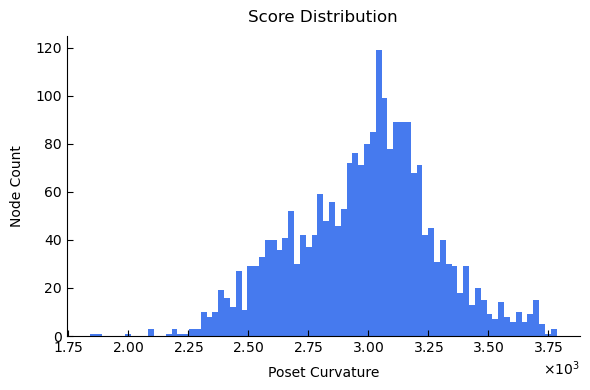

In [66]:

#scores = node_df["normalized_scalar_curvature"].values
#scores = node_df["scalar_curvature"].values
scores = node_df["abs_normalized_scalar_curvature"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)

ax.set_xlabel("Poset Curvature", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### 80% Quantile on the Normalized Curvature Histogram

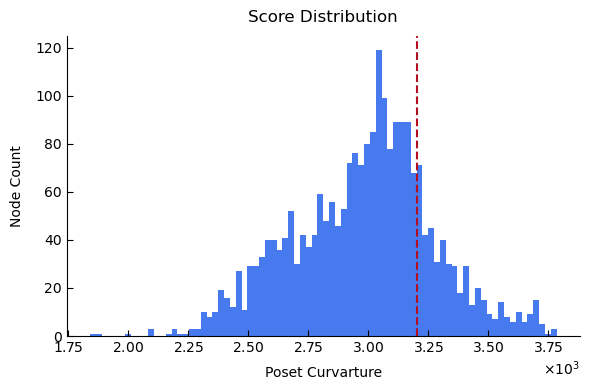

In [67]:
#p20 = node_df["scalar_curvature"].quantile(0.80)
#p20 = node_df["normalized_scalar_curvature"].quantile(0.80)
p20 = node_df["abs_normalized_scalar_curvature"].quantile(0.80)

#scores = node_df["scalar_curvature"].values
#scores = node_df["normalized_scalar_curvature"].values
scores = node_df["abs_normalized_scalar_curvature"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)
ax.axvline(p20, color="#B40F20", linestyle="--", label=f"top 10% threshold")

ax.set_xlabel("Poset Curvarture", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### Ranking Scores by Node Curvature Value (largest to smallest)

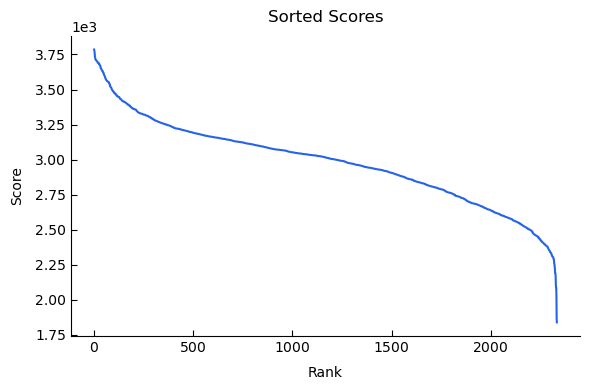

In [68]:
sorted_scores = np.sort(scores)[::-1]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(sorted_scores, lw=1.5, color="#2563eb")

ax.set_xlabel("Rank", labelpad=8)
ax.set_ylabel("Score", labelpad=8)
ax.set_title("Sorted Scores", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### Plotting Empirical CDF of the Node Curvature Scores

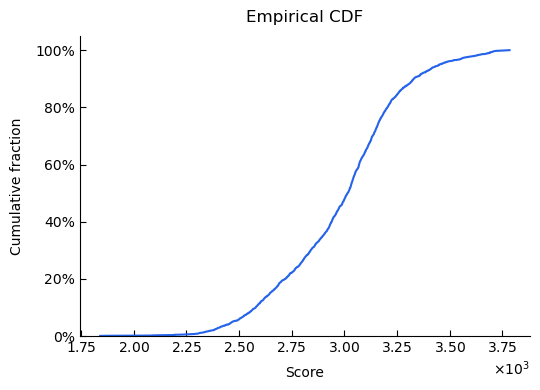

In [69]:
ecdf_x = np.sort(scores)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(ecdf_x, ecdf_y, lw=1.5, color="#2563eb")

ax.set_xlabel("Score", labelpad=8)
ax.set_ylabel("Cumulative fraction", labelpad=8)
ax.set_title("Empirical CDF", pad=10, loc="center")

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("curvature_cdf_scores.pdf", bbox_inches="tight")
plt.show()

### Thresholding the Node Curvature scores at various levels

In [70]:
# Taking the z-score of the node curvature scores.
z_scores = (scores - scores.mean()) / scores.std()

print("\nThreshold options & nodes selected:")
thresholds = {
    "Top 1%  (percentile)":    np.percentile(scores, 99),
    "Top 5%  (percentile)":    np.percentile(scores, 95),
    "Top 10% (percentile)":    np.percentile(scores, 90),
    "Top 20% (percentile)":    np.percentile(scores, 80),
    "Z-score > 2":             scores.mean() + 2 * scores.std(),
    "Z-score > 1.5":           scores.mean() + 1.5 * scores.std(),
    "IQR outliers (Q3+1.5IQR)":np.percentile(scores, 75) + 1.5 * (np.percentile(scores, 75) - np.percentile(scores, 25)),
}


for label, thresh in thresholds.items():
    n = (scores >= thresh).sum()
    print(f"  {label:<35s}  cutoff={thresh:.7f}  → {n:7d} nodes  ({100*n/len(scores):.1f}%)")

# Kneedle elbow on sorted scores
try:
    kl = KneeLocator(np.arange(len(sorted_scores)), sorted_scores,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    knee_score = sorted_scores[knee_rank] if knee_rank is not None else None
    n_knee = (scores >= knee_score).sum() if knee_score is not None else None
    print(f"  {'Kneedle elbow':<35s}  cutoff={knee_score:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(scores):.1f}%)")
    thresholds["Kneedle elbow"] = knee_score
except Exception as e:
    print(f"  Kneedle failed: {e}")


Threshold options & nodes selected:
  Top 1%  (percentile)                 cutoff=3686.9435842  →      24 nodes  (1.0%)
  Top 5%  (percentile)                 cutoff=3452.1980553  →     117 nodes  (5.0%)
  Top 10% (percentile)                 cutoff=3330.6206015  →     234 nodes  (10.0%)
  Top 20% (percentile)                 cutoff=3204.7838383  →     467 nodes  (20.0%)
  Z-score > 2                          cutoff=3570.9147317  →      61 nodes  (2.6%)
  Z-score > 1.5                        cutoff=3423.5650181  →     140 nodes  (6.0%)
  IQR outliers (Q3+1.5IQR)             cutoff=3728.9814714  →       6 nodes  (0.3%)
  Kneedle elbow                        cutoff=3313.4917094  →     269 nodes  (11.5%)


### Define Core Nodes

In [71]:
THRESHOLD_LABEL =  "Kneedle elbow"
THRESHOLD = thresholds[THRESHOLD_LABEL]

core_node_mask = scores >= THRESHOLD
node_df["is_core"] = core_node_mask

CN = node_df[core_node_mask].copy().reset_index(drop=True)

print(f"Threshold ({THRESHOLD_LABEL}): {THRESHOLD:.6f}")
print(f"Core nodes (CN): {len(CN)} / {len(node_df)}  ({100*len(CN)/len(node_df):.1f}%)")
CN.head()

Threshold (Kneedle elbow): 3313.491709
Core nodes (CN): 269 / 2335  (11.5%)


,node_id,chrom_bin,chrom,bin_start,bin_end,degree,scalar_curvature,normalized_scalar_curvature,abs_normalized_scalar_curvature,is_core
0,10,119,11,119000000,120000000,3343,-11165459,-3339.951840,3339.951840,True
1,11,34,3,34000000,35000000,3568,-12680004,-3553.812780,3553.812780,True
2,13,153,3,153000000,154000000,3392,-11487422,-3386.622052,3386.622052,True
3,15,93,6,93000000,94000000,3641,-13225816,-3632.468003,3632.468003,True
4,24,94,3,94000000,95000000,3491,-12166023,-3484.967918,3484.967918,True


### Edge Analysis

In [72]:
epath = "/scratch/indikar_root/indikar1/jduhamel/pore_c/curvature/edges_curvature.csv"
edge_df = pd.read_csv(epath)
edge_df.head()

,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature
0,0,NaN,3,NaN,5117,3054,-6270,-1045.000000
1,1,NaN,29,NaN,10804,2886,-32678,-527.064516
2,2,NaN,11,NaN,4915,3275,-22144,-1230.222222
3,3,NaN,2,NaN,1836,2819,-6292,-1258.400000
4,4,NaN,4,NaN,5998,3057,-5485,-2742.500000


In [73]:
## Modifying the curvature values
edge_val = edge_df["normalized_edge_curvature"].values
edge_mod=[]

for i in edge_val:
    edge_mod.append(abs(i))

edge_df["abs_normalized_edge_curvature"] = edge_mod

### Edge Curvature Scores - Histogram 

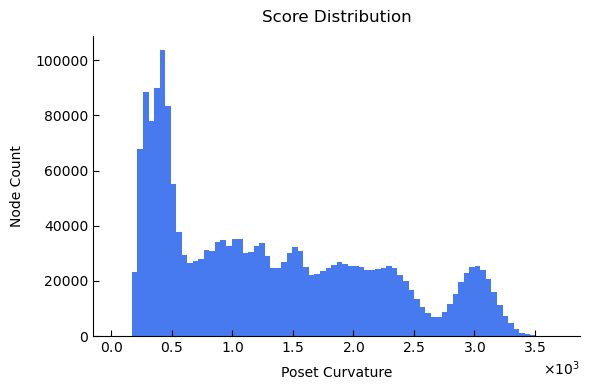

In [74]:
scores = edge_df["abs_normalized_edge_curvature"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)

ax.set_xlabel("Poset Curvature", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### 80% Quantile on the Edge Curvature Scores - Histogram

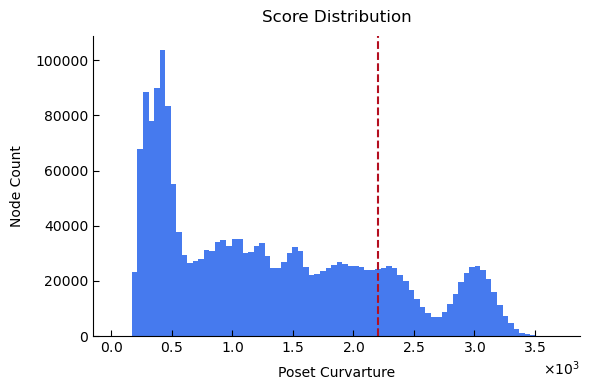

In [75]:
#p20 = node_df["scalar_curvature"].quantile(0.80)
#p20 = node_df["normalized_scalar_curvature"].quantile(0.80)
p20 = edge_df["abs_normalized_edge_curvature"].quantile(0.80)

#scores = node_df["scalar_curvature"].values
#scores = node_df["normalized_scalar_curvature"].values
scores = edge_df["abs_normalized_edge_curvature"].values

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(scores, bins=80, color="#2563eb", edgecolor="none", alpha=0.85)
ax.axvline(p20, color="#B40F20", linestyle="--", label=f"top 10% threshold")

ax.set_xlabel("Poset Curvarture", labelpad=8)
ax.set_ylabel("Node Count", labelpad=8)
ax.set_title("Score Distribution", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### Ranking Scores by Edge Curvature Scores (largest to smallest)

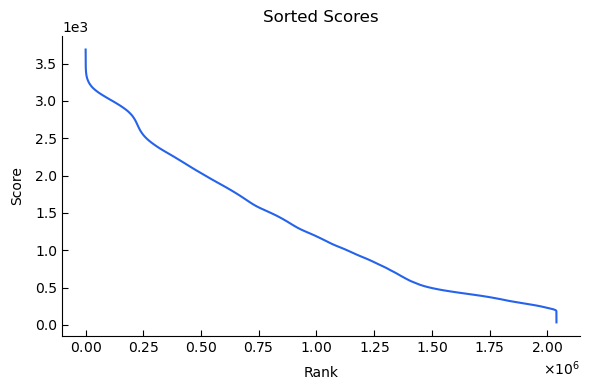

In [76]:
sorted_scores = np.sort(scores)[::-1]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(sorted_scores, lw=1.5, color="#2563eb")

ax.set_xlabel("Rank", labelpad=8)
ax.set_ylabel("Score", labelpad=8)
ax.set_title("Sorted Scores", pad=10, loc="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.tight_layout()
plt.show()

### Plotting Empirical CDF of the Edge Curvature Scores

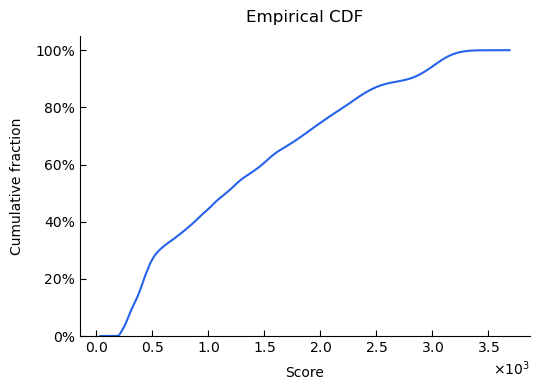

In [77]:
ecdf_x = np.sort(scores)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)

fig, ax = plt.subplots(figsize=(5.5, 4))

ax.plot(ecdf_x, ecdf_y, lw=1.5, color="#2563eb")

ax.set_xlabel("Score", labelpad=8)
ax.set_ylabel("Cumulative fraction", labelpad=8)
ax.set_title("Empirical CDF", pad=10, loc="center")

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(direction="in", length=4, width=0.8)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("curvature_cdf_scores.pdf", bbox_inches="tight")
plt.show()

### Thresholding the Edge Curvature scores at various levels

In [78]:
z_scores = (scores - scores.mean()) / scores.std()

print("\nThreshold options & nodes selected:")
thresholds = {
    "Top 1%  (percentile)":    np.percentile(scores, 99),
    "Top 5%  (percentile)":    np.percentile(scores, 95),
    "Top 10% (percentile)":    np.percentile(scores, 90),
    "Top 20% (percentile)":    np.percentile(scores, 80),
    "Z-score > 2":             scores.mean() + 2 * scores.std(),
    "Z-score > 1.5":           scores.mean() + 1.5 * scores.std(),
    "IQR outliers (Q3+1.5IQR)":np.percentile(scores, 75) + 1.5 * (np.percentile(scores, 75) - np.percentile(scores, 25)),
}


for label, thresh in thresholds.items():
    n = (scores >= thresh).sum()
    print(f"  {label:<35s}  cutoff={thresh:.7f}  → {n:7d} nodes  ({100*n/len(scores):.1f}%)")

# Kneedle elbow on sorted scores
try:
    kl = KneeLocator(np.arange(len(sorted_scores)), sorted_scores,
                     curve="convex", direction="decreasing", interp_method="polynomial")
    knee_rank  = kl.knee
    knee_score = sorted_scores[knee_rank] if knee_rank is not None else None
    n_knee = (scores >= knee_score).sum() if knee_score is not None else None
    print(f"  {'Kneedle elbow':<35s}  cutoff={knee_score:.7f}  → {n_knee:7d} nodes  ({100*n_knee/len(scores):.1f}%)")
    thresholds["Kneedle elbow"] = knee_score
except Exception as e:
    print(f"  Kneedle failed: {e}")


Threshold options & nodes selected:
  Top 1%  (percentile)                 cutoff=3216.2500000  →   20401 nodes  (1.0%)
  Top 5%  (percentile)                 cutoff=3025.6666667  →  102085 nodes  (5.0%)
  Top 10% (percentile)                 cutoff=2793.6666667  →  204030 nodes  (10.0%)
  Top 20% (percentile)                 cutoff=2205.8571429  →  407979 nodes  (20.0%)
  Z-score > 2                          cutoff=3119.9485269  →   53117 nodes  (2.6%)
  Z-score > 1.5                        cutoff=2672.3458184  →  225709 nodes  (11.1%)
  IQR outliers (Q3+1.5IQR)             cutoff=4326.9835681  →       0 nodes  (0.0%)
  Kneedle elbow                        cutoff=942.2857143  → 1174053 nodes  (57.6%)


### Define Core Edges

In [79]:
THRESHOLD_LABEL =  "Kneedle elbow"
THRESHOLD = thresholds[THRESHOLD_LABEL]

core_edge_mask = scores >= THRESHOLD
edge_df["is_core"] = core_edge_mask

CE = edge_df[core_edge_mask].copy().reset_index(drop=True)

print(f"Threshold ({THRESHOLD_LABEL}): {THRESHOLD:.6f}")
print(f"Core Edges (CN): {len(CE)} / {len(edge_df)}  ({100*len(CE)/len(edge_df):.1f}%)")
CE.head()

Threshold (Kneedle elbow): 942.285714
Core Edges (CN): 1174053 / 2039865  (57.6%)


,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature,abs_normalized_edge_curvature,is_core
0,0,NaN,3,NaN,5117,3054,-6270,-1045.000000,1045.000000,True
1,2,NaN,11,NaN,4915,3275,-22144,-1230.222222,1230.222222,True
2,3,NaN,2,NaN,1836,2819,-6292,-1258.400000,1258.400000,True
3,4,NaN,4,NaN,5998,3057,-5485,-2742.500000,2742.500000,True
4,6,NaN,12,NaN,8375,3057,-12882,-1288.200000,1288.200000,True


In [80]:
# # Build H submatrix restricted to CN rows
# cn_row_positions = np.where(core_ege_mask)[0]   # positions in filtered H

# H_cn = H[cn_row_positions, :]                    # (|CN| × n_hyperedges)

# # A core edge must contain ONLY CN nodes:
# #   total contacts in hyperedge == contacts from CN nodes only
# total_contacts = np.asarray(H.sum(axis=0)).ravel()   # all nodes
# cn_contacts    = np.asarray(H_cn.sum(axis=0)).ravel()  # CN nodes only

# only_ce_mask = (cn_contacts == total_contacts) & (total_contacts > 0)

In [81]:
# Combined CE mask
# ce_mask = only_ce_mask

# CE_var_positions = np.where(ce_mask)[0]           # positions in filtered H cols
# CE_adata_var_idx = var_idx[CE_var_positions]      # original adata.var indices

# CE = adata.var.iloc[CE_adata_var_idx].copy().reset_index(drop=True)

# print(f"\nHyperedge filtering summary:")
# print(f"  Total filtered hyperedges:       {H.shape[1]:>8,}")
# print(f"  Contain only CN nodes:           {only_ce_mask.sum():>8,}  ({100*only_ce_mask.sum()/H.shape[1]:.1f}%)")
# #print(f"  + Have ≥1 gene (CE):             {ce_mask.sum():>8,}  ({100*ce_mask.sum()/H.shape[1]:.1f}%)")
# print(f"\nCore edges (CE): {len(CE)}")
# CE.head()

### Writing Core Nodes and Edges to a CSV

In [82]:
CN.to_csv("core_nodes_curvature.csv", index=False)
CE.to_csv("core_edges_curvature.csv", index=False)

# Core submatrix
H_core = H[np.ix_(cn_row_positions, CE_var_positions)]
sp.save_npz("H_core_curvature.npz", H_core.tocsr())

print("Saved: core_nodes.csv, core_edges.csv, H_core.npz")
print(f"\nCore incidence matrix H_core shape: {H_core.shape}")
print(f"  rows = CN nodes, cols = CE hyperedges")
print(f"\nCN chromosomes:\n{CN['chrom'].value_counts().to_string()}")
print(f"\nCE gene summary:\n{CE[['n_genes','genes']].describe()}")

Saved: core_nodes.csv, core_edges.csv, H_core.npz

Core incidence matrix H_core shape: (269, 31983)
  rows = CN nodes, cols = CE hyperedges

CN chromosomes:
chrom
8     70
6     64
3     45
11    27
5     16
7      9
17     7
16     6
2      4
13     4
14     3
1      3
12     2
4      2
9      2
18     1
15     1
10     1
X      1
19     1


KeyError: "None of [Index(['n_genes', 'genes'], dtype='object')] are in the [columns]"